In [17]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# Naive Bayes
class MyMultinomialNB:
    """
    Hiện thực thuật toán Multinomial Naive Bayes từ đầu.
    Sử dụng kỹ thuật Log-probabilities để tránh underflow và Laplace Smoothing.
    """
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_log_priors = None  # Log P(c)
        self.feature_log_probs = None # Log P(x_i | c)
        self.classes = None

    def fit(self, X, y):
        # Chuyển đổi nhãn y thành numpy array để xử lý dễ dàng hơn
        y = np.array(y)

        self.classes = np.unique(y)
        n_classes = len(self.classes)
        n_features = X.shape[1]

        self.class_log_priors = np.zeros(n_classes)
        self.feature_log_probs = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes):
            # Lấy các dòng dữ liệu thuộc lớp c
            # X là sparse matrix từ TfidfVectorizer
            X_c = X[y == c]

            # --- Tính Log Prior: P(c) ---
            self.class_log_priors[idx] = np.log(X_c.shape[0] / X.shape[0])

            # --- Tính Log Likelihood: P(x_i | c) ---
            # Tổng số trọng số TF-IDF của mỗi từ trong lớp c
            # .sum(axis=0) trả về matrix 2D (1, n_features) -> chuyển về 1D bằng .A1
            word_count_in_class = X_c.sum(axis=0).A1

            # Tổng trọng số của toàn bộ từ trong lớp c
            total_words_in_class = word_count_in_class.sum()

            # Áp dụng Laplace Smoothing: (count + alpha) / (total + alpha * V)
            numerator = word_count_in_class + self.alpha
            denominator = total_words_in_class + (self.alpha * n_features)

            # Lưu log xác suất
            self.feature_log_probs[idx, :] = np.log(numerator / denominator)

        print("-> Đã khởi tạo và sẵn sàng huấn luyện mô hình MyMultinomialNB!")
        return self

    def predict(self, X):
        # Tính Log Likelihood cho dữ liệu mới
        # Công thức: log P(c) + sum(log P(x_i|c))
        # Phép nhân ma trận X @ T thay thế cho việc sum
        jll = X @ self.feature_log_probs.T

        # Cộng thêm Log Prior
        jll += self.class_log_priors

        # Tìm lớp có xác suất lớn nhất (MAP estimate)
        indices = np.argmax(jll, axis=1)

        return self.classes[indices]

# Tiền xử lý dữ liệu
def preprocess_fast(text):
    # 1. Chuyển chữ thường
    text = text.lower()
    # 2. Xóa HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 3. Xóa ký tự đặc biệt/số (giữ lại chữ cái và khoảng trắng)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # 4. Gộp khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text)
    # 5. Xử lý phủ định (QUAN TRỌNG): not good -> not_good
    text = re.sub(r'\bnot\s+(\w+)\b', r'not_\1', text)
    # 6. Tách từ và loại bỏ stop words
    words = text.split()
    # Lưu ý: 'not' nằm trong ENGLISH_STOP_WORDS nhưng các từ 'not_good' sẽ được giữ lại
    words = [w for w in words if w not in ENGLISH_STOP_WORDS]

    return ' '.join(words)

In [19]:
reviews = pd.read_csv("IMDB Dataset.csv")

In [20]:
reviews

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [21]:
reviews['clean_review'] = reviews['review'].apply(preprocess_fast)

In [22]:
X = reviews['clean_review']
y = reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
# --- TRÍCH XUẤT ĐẶC TRƯNG (TF-IDF) ---
# TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1,3))
# Học từ vựng từ tập Train và biến đổi
X_train_tfidf = tfidf.fit_transform(X_train)
# Chỉ biến đổi tập Test (từ lạ sẽ bị bỏ qua tự động)
X_test_tfidf = tfidf.transform(X_test)
# print(f"- Kích thước ma trận Train: {X_train_tfidf.shape}")
# print(f"- Kích thước ma trận Test: {X_test_tfidf.shape}")

In [24]:
nb = MyMultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)
y_pred = nb.predict(X_test_tfidf)

-> Đã khởi tạo và sẵn sàng huấn luyện mô hình MyMultinomialNB!


In [25]:
# --- ĐÁNH GIÁ KẾT QUẢ ---
print("\n=== KẾT QUẢ ĐÁNH GIÁ ===")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== KẾT QUẢ ĐÁNH GIÁ ===
Accuracy: 0.8608

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      4961
    positive       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [26]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[4191  770]
 [ 622 4417]]


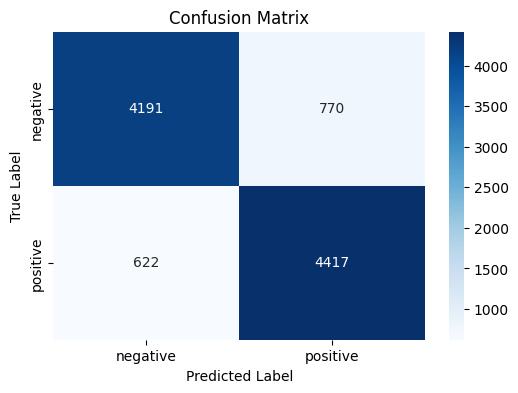

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["negative", "positive"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


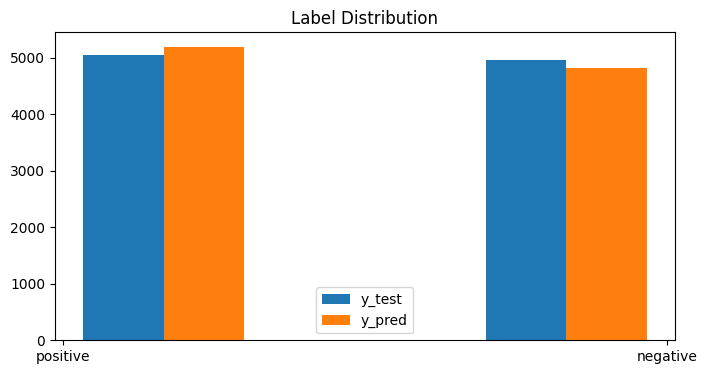

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist([y_test, y_pred], bins=3, label=["y_test", "y_pred"])
plt.legend()
plt.title("Label Distribution")
plt.show()


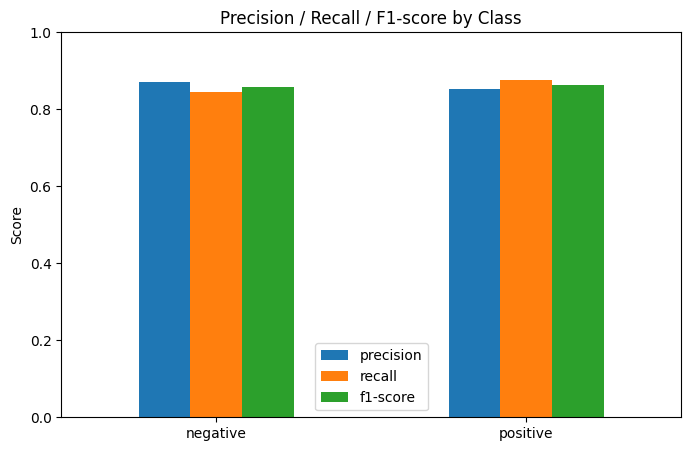

In [29]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose().iloc[:2, :3]   # chỉ lấy 2 class

df.plot(kind='bar', figsize=(8,5))
plt.title("Precision / Recall / F1-score by Class")
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()
